In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import h5py
import numpy as np

In [ ]:
load_path = "./drive/MyDrive/gsgm_splits_128.h5"

with h5py.File(load_path, "r") as f:
    X_train = f["X_train"][:]   # shape (547, 128, 128, 17)
    Y_train = f["Y_train"][:]   # shape (547, 128, 128, 1)
    X_val   = f["X_val"][:]     # shape (117, 128, 128, 17)
    Y_val   = f["Y_val"][:]     # shape (117, 128, 128, 1)
    X_test  = f["X_test"][:]    # shape (118, 128, 128, 17)
    Y_test  = f["Y_test"][:]    # shape (118, 128, 128, 1)

print("Loaded shapes:")
print("Train:", X_train.shape, Y_train.shape)
print("Val  :", X_val.shape,   Y_val.shape)
print("Test :", X_test.shape,  Y_test.shape)

Loaded shapes:
Train: (1442, 128, 128, 17) (1442, 128, 128, 1)
Val  : (309, 128, 128, 17) (309, 128, 128, 1)
Test : (310, 128, 128, 17) (310, 128, 128, 1)


## Understand Intution (why HUAL is needed to further train the Multimodal Attention U-net(already trained))

- HUAL does not replace the base Attention u-net model
- HUAL is a strategy that decides what to label next so that the same model becomes better with less human work.

**Where base trained u-net model fails**

- The model correctly identified glacier vs non-glacier
- But struggled near boundaries, especially:
  - debris-covered ice
  - snow-ice transitions
  - shadowed regions

**"The model knows what a glacier looks like, but is unsure where exactly it ends"**

This uncertainty is localized, not everywhere.

- **Normal Training**
  - boundary pixels contributes = 5-10% of loss
  - interior pixels dominate learning
  - model sees that many of the pixels which are glacier are white and clear but the glacier near boundaries are not clear hence the model is getting confused between glacier/non-glacier.
  

- **HUAL training**
  - here mostly the model is shown the boundary pixels/patches where the model is most confused.
  - so boundary pixels contributes = 50-70% of loss
  - model emphasis changes to boundary pixels instead of interior pixels as during normal training model was able to capture the pattern of interior pixels but not of the boundary pixels.
  So now we show the model more of boundary pixels and hence it contributes to more loss and the model learns the patter to reduce the loss.






## Purpose of HUAL
We reduce glacier annotation cost by focusing labelling effort only on uncertain and unexplored regions using Hierarichal Uncertainity-Aware Active Learning, while maintaining near-baseline segmentation accuracy

#### Contribution:
We integrate HUAL with multimodal glacier segmentation to reduce annotation cost while preserving accuracy



- Step 1: Intial trained Multimodal Attention U-Net

- Step 2: Uncertainty Estimation using MC Dropout:
We estimate pixel-wise uncertainty by running the trained model multiple times with dropout enabled and measuring how much the prediction vary.


  - Pick one image
    
    image = x_test[k] -> shape (c,h,w)

  - run model multiple times (k times)
    Each run:
    - Dropout randomly disables neurons
    - same image, same weights
    - slightly different internal computation

    you get,

    run 1 -> probability map p1 (h*w)

    run k -> probability map pk (h*w)

    now stack them,

    p_stack -> shape (k,h,w)


    Now focus on one pixel,

    take pixel (i,j) from p_stack, you have,

    [p1(i,j), p2(i,j), ... , pk(i,j)]

    these are 'k' probability estimates for the same pixel

**Case 1:** Confident pixel (glacier interior)
[0.97, 0.96, 0.98, 0.96]
- all values are high
- all values are similar
- model agrees with itself

Hence, **Low Uncertainty**

**Case 2:** Uncertain pixel (boundary/debris)

[0.42, 0.61, 0.35, 0.58]
- values fluctuate
- sometimes glacier, sometimes not
- model disagrees with itself

Hence, **High uncertainty**



#### How uncertainty is COMPUTED mathematically
for each pixel (i,j) we compute one number from those K values.

Two common choices:
1. **Variance-based uncertainty**
"How much do these values vary?"
- small variance -> confident
- large variance -> uncertain

2. **Entropy-based uncertainty**
Entropy = uncertainty/confusion/randomness
- **Low entropy** -> model is confident
* **High entropy** -> model is confused

"How unsure is the model about this pixel"

Suppose for one pixel the average predicted probability is:
**Case A:** Very confident
Mean prob = 0.98
the model is saying:
"This is glacier. I'm sure"

- **Low entropy**

**Case B:** Very uncertain
Mean prob = 0.50
the model is saying:
"I really dont know"

- **High entropy**

**Case C:** Confident background
Mean prob = 0.02
the model is saying:
"Definitely not glacier"

- **Low entropy**

Key idea:
Entropy is highest near 0.5 and lower near (0 or 1)
This is exactly what we want for boundary detection.

Entropy formulae:
H(p) = -[plog(p) + (1-p)log(1-p)]
where,
p = mean probability for that pixel
This formuale:
- peaks at p = 0.5
- goes to 0 at p = 0 or p = 1



#### What problem percentile-based selection solves
Imagine this situation:
- You compute uncertainty for many glacier images
- Each image has thousands of pixels
- Each pixel has an uncertaint value

Now question arises:

**Which pixels/patches/images should i ask a human to label?**


**Bad approach**
- Use a fixed threshold like "entropy > 0.7"
- Why bad ?

  -> Different images have different uncertainty ranges

  -> Some images are easy, some are hard


##### Percentile-based selection
Instead of asking **"how big is the uncertainty?"**, we ask **"how uncertain is this compared to others?"**


Glacier Analogy
Think of many glacier images taken from different regions:
- Image A: clear glacier, low noise
- Image B: debris-covered glacier
- Image C: shadow-heavy scene
- Image D: complex terrain
Each image has different
uncertainty scales


If we say:
**Top 10% uncertain pixels**
It means:
- Sort all pixels by uncertainty
- pick the most uncertain 10%
- Ignore the rest

It does not matter:
- what the actual uncertainty value is

**Percentile selection ensures:**
- we pick only important most uncertain regions relative to other pixels in an image
- this helps in reducing the annotation cost by annotating only those pixels which are most confusing (suppose top 10%) pixels.
- this the core benefit of HUAL


**HUAL starts by finding the most confusing pixels, groups them into small regions(patches), and then decides which glacier images are worth annotating based on how many confusing regions they contain.**

**Why we need Patches ?**
If i tell you:
"Please label these 500 pixels"
You'll say no.
But if i say:
"Please correct this small region around the boundary"
You'll say yes.
So we group pixels into patches

#### Pixel -> Patch (How grouping works conceptually)
Imaging dividing the image into:
- Small square regions(patches)
eg. 32*32 or 64*64 pixels
now for each patch, ask:
"How many of the highly uncertain pixels fall inside this patch?"

Each patch gets one uncertainty score based on
- count or avg of uncertain pixel inside it
- now we've moved from **"Which pixels are confusing?"** to **"Which regions are confusing"**

Now do the same percentile idea again, but at patch level
For an image:
- Rank patches by uncertainty
- Select top k patches

These are:
- The most confusing regions of this image
- Exactly where annotation is most useful


#### Patch -> Image (across many iamges)
we have
- Many glacier images
- Each image has multiple patches
- Each patch has an uncertainty score

Now ask:

**"Which images contain the most confusing regions?"**

**How image-level uncertainty is computed**
For each image:
- Loook at its top uncertain patches
- Aggregate them (e.g. average or sum)

If an image has:
- Many highly uncertain patches: Hard iamge
- Few uncertain patches: easy image


##### Glacier intuition
**Image A(simple glacier)**
- clean snow
- clear boundary
- few uncertain patches

Hence, **Low image uncertainty**


** Image B(complex glacier)**
- Debris-covered ice
- shadows
- irregular boundary

Hence, **High image uncertainty** because of **Many uncertain patches**


#### Image percentile (Final selection)
Now you do percentile selection across images:
- Rank images by uncertainty
- Select top M images for nnotation

These are:
- the most informative glacier images
- The ones where human input helps most


### **Final flow (That's why it is called Hierarichal uncertainty-Aware Learning)**

**Pixels (uncertainty per pixel)**

   ↓ percentile

**Selected pixels**

   ↓ grouping

**Patches (uncertainty per patch)**

   ↓ percentile

**Selected patches**

   ↓ aggregation

**Images (uncertainty per image)**

   ↓ percentile

**Selected images for annotation**

### **Why this hierarchy is powerful**
- Pixel-level: precise
- patch-level: human-friendly
- image-level: scalable

It avoids:
- Labelling whole images
- Labelling random regions
- Re-labelling easy areas



### **The problem HUAL still has without distance-based exploration**

Image annotating glaciers without distance-based exploration

What will happen naturally ?
- the model is most confused at one particular boundary
- the boundary keeps appearing very uncertain

Result:
- You waste annotation effort
- Other glacier parts remain unseen
- The model becomes locally good, not globally good


**Distance-based exploration forces the model to look at new, unexplored glacier regions of repeatedly selecting the same area**

**Let me annotate boundaries that are both confusing and far from what i already fixed**


Formulate it iteration wise:
**Iteration 1**
- boundary A is most uncertain
- you annotate patch A1

**Iteration 2**
- boundary A(near A1) still uncertain
- model selects patch A2 (very close to A1)

**Iteration 3**
- boundary A still slightly uncertain
- model selects patch A3

Meanwhile:
- Boundary B untoched
- Boundary C untoched

This is a wasted effort


### What happens with HUAL (iteration-wise)

**Iteration 1**
- boundary A very uncertain
- Annotate patch A1

**Iteration 2**
- boundary A less uncertain
- boundary B now more uncertain
- Annotate patch B1

**Iteration 3**
- boundary C most uncertain
- annotate patch C1

**Iteration 4**
- Some uncertainty remains
- But now improvement per annotation is low
- We stop

**We stop when marginal gain becomes small, not when uncertainty is zero**



### **so what does HUAL really save ?**

HUAL saves you from:

- Annotating easy regions
  - Clear snow
  - clear rock
  - flat interior glacier

- Annotating the same region repeatedly
  - over-polishing boundary A
  - ignoring B and C

- Annnotating entire images
  - when only 10% is problematic





### **Budget means in glacier mapping**

Budget = how much human effort you can need

in glacier segmentation, budget is Not money, it is:
- Number of images annotated
- Number of patches corrected
- Number of pixels manually labelled
- Time spent by an expert




**Active learning is terminated when segmentation performance saturates and uncertainty maps stabilize, indicating diminishing returns from further annotation**

**HUAL does not claim:**
- perfect boundaries everywhere
- zero uncertainty
- no annotation needed

**HUAL claims**
- focussed annotation
- focussed effort
- near-baseline performance with reduced cost




In [ ]:
# Step 1: Uncertainty (Entropy) computation
"""
for each training patch, compute:
1. model prediction
2. pixel-wise uncertainty map
"""

import torch
import numpy as np

def to_tensor_channels_first(X_np):
    """
    Converts (N, H, W, C) numpy array
    → (N, C, H, W) torch tensor
    """
    X = torch.from_numpy(X_np).float()
    X = X.permute(0, 3, 1, 2)   # NHWC → NCHW
    return X

X_train_t = to_tensor_channels_first(X_train)
print(X_train_t.shape)

torch.Size([1442, 17, 128, 128])


In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.6 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp

model = None
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.mkldnn.enabled = (DEVICE == "cpu")

def make_strong_unet(in_channels):
    """
    Multimodal-ready U-Net with SCSE attention.
    ImageNet weights are DISABLED because input channels != 3.
    """
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,          # 🔴 MUST be None for 16-channel input
        in_channels=in_channels,       # e.g., 17
        classes=1,
        activation=None,
        decoder_attention_type="scse",
        encoder_depth=5,
        decoder_channels=[256,128,64,32,16]
    )
    return model.to(DEVICE)


In [ ]:
def load_model(model_path):
  global model

  checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
  print(checkpoint.keys())

  in_channels = X_test.shape[-1]  # = 17 in your case

  model = make_strong_unet(in_channels)
  model.load_state_dict(checkpoint["model_state_dict"])
  model.to(DEVICE)
  model.eval()

# load the pretrained model
load_model("unet_best_glacier.pth")


dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_threshold', 'val_dice', 'scheduler_state_dict'])


In [ ]:
# predictive entropy

def predict_probability_maps(model, X, batch_size=8, device="cpu"):
    """
    Runs model inference and returns probability maps
    Output shape: (N, 1, H, W)
    """
    model.eval()
    model.to(device)

    probs_all = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = X[i:i+batch_size].to(device)
            logits = model(xb)              # (B, 1, H, W)
            probs = torch.sigmoid(logits)   # probability
            probs_all.append(probs.cpu())

    return torch.cat(probs_all, dim=0)

probs_train = predict_probability_maps(model, X_train_t, device=DEVICE)
print(probs_train.shape)  # (547, 1, 128, 128)


torch.Size([1442, 1, 128, 128])


In [ ]:
# compute pixel-wise entropy
# entropy gives us the model confusion
def compute_entropy_map(probs, eps=1e-6):
    """
    probs: (N, 1, H, W) tensor in [0,1]
    returns entropy map of same shape
    """
    entropy = -(
        probs * torch.log(probs + eps) +
        (1 - probs) * torch.log(1 - probs + eps)
    )
    return entropy

entropy_train = compute_entropy_map(probs_train)
print(entropy_train.shape)  # (547, 1, 128, 128)

torch.Size([1442, 1, 128, 128])


In [ ]:
i = 0  # any patch index
print("Max entropy:", entropy_train[i].max().item())
print("Min entropy:", entropy_train[i].min().item())

Max entropy: 0.687367856502533
Min entropy: 4.486740635911701e-06


In [ ]:
# percentile thresholding function

def percentile_uncertainty_mask(entropy_map, percentile=90):
    """
    entropy_map: (1, H, W) tensor for ONE patch
    returns binary mask of same shape
    """
    flat = entropy_map.view(-1)
    thresh = torch.quantile(flat, percentile / 100.0)
    mask = entropy_map >= thresh
    return mask

def compute_uncertainty_masks(entropy_all, percentile=90):
    """
    entropy_all: (N, 1, H, W)
    returns: (N, 1, H, W) binary masks
    """
    masks = []
    for i in range(len(entropy_all)):
        m = percentile_uncertainty_mask(entropy_all[i], percentile)
        masks.append(m)
    return torch.stack(masks)


uncertainty_masks = compute_uncertainty_masks(entropy_train, percentile=90)
print(uncertainty_masks.shape)


torch.Size([1442, 1, 128, 128])


In [ ]:
"""
Instead of giving a particular threshold
we choose the most 10% uncertain pixels whose entropy > 90 percentile
"""

i = 0
num_uncertain = uncertainty_masks[i].sum().item()
total_pixels = 128 * 128

print("Uncertain pixels:", num_uncertain)
print("Percentage:", 100 * num_uncertain / total_pixels)


Uncertain pixels: 1639
Percentage: 10.003662109375


In [ ]:
# patch uncertainty scoring function
"""
We aggregate pixel-level uncertainty into a patch-level uncertainty score by measuring
the proportion of highly uncertain pixels, allowing us to prioritize patches that contain
complex glacier boundaries for human annotation.
"""
"""
If a patch has
1. 2% uncertain pixels -> mostly easy
2. 10% uncertain pixels -> moderately hard
3. 25% uncertain pixels -> very hard boundary patch

Higher score = better candidate for HUAL

but the realization is:
Eg.
Patch A (very easy)
- Max entropy = 0.05
- Still has a top 10% (because percentile logic forces it)

Patch B (very hard)
- Max entropy = 0.5
- Also has a top 10%

Now both patches have 10% uncertain pixels

But clearly,
- Patch B is much harder
- Patch A is barely uncertain at all

So,
Percentile makes "percentage of uncertain pixels" meaningless across patches.

Why we changed patch scoring to mean entropy ?

We needed a score that answers:
"Is this patch more confused than others?"

Easy patch:
- All pixels have low entropy
- Mean ~ 0.02

Hard patch:
- Many pixels have moderate/high entropy
- Mean ~ 0.15+

So now,
- Easy vs hard patches are seperable
- Ranking makes sense again
"""

def patch_uncertainty_score(entropy_map):
    """
    entropy_map: (1, H, W) tensor for ONE patch
    returns: scalar uncertainty score
    """
    return entropy_map.mean().item()


def compute_patch_uncertainty_scores(entropy_all):
    scores = []
    for i in range(len(entropy_all)):
        scores.append(patch_uncertainty_score(entropy_all[i]))
    return scores


patch_scores = compute_patch_uncertainty_scores(entropy_train)

print("Min:", min(patch_scores))
print("Max:", max(patch_scores))


Min: 0.0011422918178141117
Max: 0.15091614425182343


In [ ]:
print("Overall patches", len(patch_scores))
print("List of top 10 patches which are most uncertain compared to others", sorted(patch_scores, reverse=True)[:10])

Overall patches 1442
List of top 10 patches which are most uncertain compared to others [0.15091614425182343, 0.15080493688583374, 0.15074525773525238, 0.15062108635902405, 0.1506022810935974, 0.1505350023508072, 0.15030814707279205, 0.15013530850410461, 0.1500079333782196, 0.1499330848455429]


In [ ]:
# Sort patches by uncertainty

patch_scores = np.array(patch_scores)
sorted_indices = np.argsort(-patch_scores)  # descending order


In [ ]:
# Select top-k patches (your annotation budget)

K = 400
selected_patch_indices = sorted_indices[:K]

In [ ]:
print("Total selected indices as per HUAL criteria", len(selected_patch_indices))

Total selected indices as per HUAL criteria 400


In [ ]:
# Extract selected patches (inputs)

def extract_selected_patches(X, indices):
    """
    X: numpy array (N, H, W, C)
    indices: list or array of selected patch indices
    returns: selected patches
    """
    return X[indices]

# Extract corresponding ground truth (labels)

def extract_selected_labels(Y, indices):
    """
    Y: numpy array (N, H, W, 1)
    indices: list or array of selected patch indices
    returns: selected GT masks
    """
    return Y[indices]

In [ ]:
X_hual = extract_selected_patches(X_train, selected_patch_indices)
print(X_hual.shape)

(400, 128, 128, 17)


In [ ]:
Y_hual = extract_selected_labels(Y_train, selected_patch_indices)
print(Y_hual.shape)

(400, 128, 128, 1)


In [ ]:
"""
What X_hual and Y_hual represents conceptually ?

Each (X_hual[i], Y_hual[i]) pair is:
- A hard glacier boundary patch that a human carefully annotated

In real deployment:
- Human would draw/refine boundary
- Here, we reuse Ground Truth to simulate that effort

We are NOT:
- Re-labelling everything
- Training a new model
- Changing architecture

We are:
- Adding extra attention to rare, hard glacier boundary cases

The selected high-uncertainty patches are presented for human annotation
but in our experiments, this is simulated by extracting the corresponding
ground-truth masks, which are then added to the training set for focussed retraining.
"""

'\nWhat X_hual and Y_hual represents conceptually ?\n\nEach (X_hual[i], Y_hual[i]) pair is:\n- A hard glacier boundary patch that a human carefully annotated \n\nIn real deployment:\n- Human would draw/refine boundary\n- Here, we reuse Ground Truth to simulate that effort\n\nWe are NOT:\n- Re-labelling everything\n- Training a new model\n- Changing architecture\n\nWe are:\n- Adding extra attention to rare, hard glacier boundary cases\n\nThe selected high-uncertainty patches are presented for human annotation\nbut in our experiments, this is simulated by extracting the corresponding \nground-truth masks, which are then added to the training set for focussed retraining.\n'

In [ ]:
print("HUAL patches:", X_hual.shape)
print("HUAL labels :", Y_hual.shape)


HUAL patches: (400, 128, 128, 17)
HUAL labels : (400, 128, 128, 1)


In [ ]:
# Create the HUAL Training Dataset
"""
- Base training taught the model, "What a glacier usually looks like"
- HUAL patches teach the model, "These boundary cases are important - pay extra attention"

Now we must combine both so the model:
- does not forget easy interiors
- but learns boundaries much better

HUAL = Original training data + selected uncertain patches

Notice:
- HUAL patches are duplicated examples
- Same label, same region

But showing them is intentional because repetition of hard cases:
- increases their contribution to loss
- forces the optimizer to care
This is how boundary learning improves.
"""

def build_hual_dataset(X_base, Y_base, X_hual, Y_hual):
    """
    Combines base dataset with HUAL-selected patches
    """
    X_combined = np.concatenate([X_base, X_hual], axis=0)
    Y_combined = np.concatenate([Y_base, Y_hual], axis=0)
    return X_combined, Y_combined


X_hual_train, Y_hual_train = build_hual_dataset(
    X_train, Y_train, X_hual, Y_hual
)

print("HUAL Train X:", X_hual_train.shape)
print("HUAL Train Y:", Y_hual_train.shape)


HUAL Train X: (1842, 128, 128, 17)
HUAL Train Y: (1842, 128, 128, 1)


In [ ]:
# ------------ Loss Functions --------------
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        dims = (2, 3)
        intersection = (probs * targets).sum(dim=dims)
        denominator = probs.sum(dim=dims) + targets.sum(dim=dims)
        dice = (2 * intersection + self.smooth) / (denominator + self.smooth)
        return 1 - dice.mean()


class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=1.0, bce_weight=1.0):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        dice_loss = self.dice(logits, targets)
        bce_loss = self.bce(logits, targets)
        return self.dice_weight * dice_loss + self.bce_weight * bce_loss


In [ ]:
# Convert numpy arrays to torch tensors (NCHW format)
def numpy_to_torch(X_np, Y_np):
    X = torch.from_numpy(X_np).float().permute(0, 3, 1, 2)  # NCHW
    Y = torch.from_numpy(Y_np).float().permute(0, 3, 1, 2)
    return X, Y

# Create dataloader
def create_dataloader(X, Y, batch_size=8, shuffle=True):
    dataset = TensorDataset(X, Y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# HUAL-specific training parameters
HUAL_BATCH_SIZE = 8
HUAL_LR = 1e-4
HUAL_EPOCHS = 10

print("Converting HUAL data to tensors...")
X_hual_t, Y_hual_t = numpy_to_torch(X_hual_train, Y_hual_train)

hual_loader = create_dataloader(
    X_hual_t,
    Y_hual_t,
    batch_size=HUAL_BATCH_SIZE,
    shuffle=True
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

model.to(DEVICE)
model.train()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=HUAL_LR,
    weight_decay=1e-5
)

criterion = DiceBCELoss(dice_weight=1.0, bce_weight=1.0)

Converting HUAL data to tensors...
Using device: cpu


In [ ]:
from tqdm import tqdm

def hual_retrain(model, loader, optimizer, criterion, epochs):
    print("\n" + "="*50)
    print(f"Starting HUAL Retraining for {epochs} epochs")
    print("="*50)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = len(loader)

        # Progress bar for the epoch
        progress_bar = tqdm(enumerate(loader), total=num_batches,
                            desc=f"Epoch {epoch+1}/{epochs}",
                            leave=False)

        for batch_idx, (xb, yb) in progress_bar:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

            # Update progress bar with current loss
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Avg': f'{epoch_loss/(batch_idx+1):.4f}'
            })

        avg_loss = epoch_loss / num_batches
        print(f"\nHUAL Epoch [{epoch+1}/{epochs}] - Final Avg Loss: {avg_loss:.4f}")

    print("HUAL Retraining completed!")

In [ ]:
hual_retrain(model, hual_loader,optimizer, criterion, epochs=HUAL_EPOCHS)

torch.save(model.state_dict(), "unet_hual_finetuned.pth")
print("Fine-tuned model saved as 'unet_hual_finetuned.pth'")



Starting HUAL Retraining for 10 epochs



HUAL Epoch [1/10] - Final Avg Loss: 0.0804



HUAL Epoch [2/10] - Final Avg Loss: 0.0527



HUAL Epoch [3/10] - Final Avg Loss: 0.0359



HUAL Epoch [4/10] - Final Avg Loss: 0.0164


...


HUAL Epoch [6/10] - Final Avg Loss: 0.0090



HUAL Epoch [7/10] - Final Avg Loss: 0.0095



HUAL Epoch [8/10] - Final Avg Loss: 0.0084



HUAL Epoch [9/10] - Final Avg Loss: 0.0052



HUAL Epoch [10/10] - Final Avg Loss: 0.0046
HUAL Retraining completed!
Fine-tuned model saved as 'unet_hual_finetuned.pth'


In [ ]:
# Lets evaluate the HUAL-fine tuned model
# Checking whether HUAL actually improved segmentation accuracy compared to the base model

# Convert validation/test data to torch
X_test_t = torch.from_numpy(X_test).float().permute(0, 3, 1, 2)
Y_test_t = torch.from_numpy(Y_test).float().permute(0, 3, 1, 2)

test_loader = DataLoader(TensorDataset(X_test_t, Y_test_t), batch_size=8, shuffle=False)

In [ ]:
def compute_dice(preds, targets, threshold=0.5, eps=1e-6):
    preds = torch.sigmoid(preds) > threshold
    targets = targets.bool()

    intersection = (preds & targets).sum(dim=(1,2,3)).float()
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))

    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()

def compute_iou(preds, targets, threshold=0.5, eps=1e-6):
    preds = torch.sigmoid(preds) > threshold
    targets = targets.bool()

    intersection = (preds & targets).sum(dim=(1,2,3)).float()
    union = (preds | targets).sum(dim=(1,2,3)).float()

    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()


In [ ]:
def evaluate_model(model, loader, device):
    model.eval()
    dice_scores = []
    iou_scores = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)

            dice_scores.append(compute_dice(logits, yb))
            iou_scores.append(compute_iou(logits, yb))

    return {
        "Dice": sum(dice_scores) / len(dice_scores),
        "IoU":  sum(iou_scores) / len(iou_scores)
    }

In [ ]:
metrics_hual = evaluate_model(model, test_loader, DEVICE)

In [ ]:
print("HUAL Model Performance:")
print(f"Dice: {metrics_hual['Dice']:.4f}")
print(f"IoU : {metrics_hual['IoU']:.4f}")

HUAL Model Performance:
Dice: 0.9986
IoU : 0.9973


## Why the absolute values are so high ?
- The baseline model already performs strongly on this patch-based dataset.
- The role of HUAL is not to dramatically increase overall accuracy, but to selectively refine ambiguous glacier boundary regions and achieve comparable or slightly improved performance with substantially reduced annotation effort.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class GlacierDataset(Dataset):
    def __init__(self, X, Y):
        self.X = np.ascontiguousarray(X.astype(np.float32))
        self.Y = np.ascontiguousarray(Y.astype(np.float32))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.X[idx]).permute(2, 0, 1)   # (C,H,W)
        mask = torch.from_numpy(self.Y[idx]).permute(2, 0, 1)
        return img, mask

In [ ]:
# visualization function between Multi-patch base model vs HUAL model
import matplotlib.pyplot as plt

def visualize_base_vs_hual_predictions(base_model, hual_model, dataset, idx_list, threshold, device, channel=0):
    base_model.eval()
    hual_model.eval()

    for idx in idx_list:
        img, gt = dataset[idx]
        img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            base_pred = torch.sigmoid(base_model(img))
            hual_pred = torch.sigmoid(hual_model(img))

            base_pred = (base_pred >= threshold).float()
            hual_pred = (hual_pred >= threshold).float()

        # Convert to numpy
        img_np  = img.cpu().numpy()[0, channel]
        gt_np   = gt.numpy()[0]
        base_np = base_pred.cpu().numpy()[0, 0]
        hual_np = hual_pred.cpu().numpy()[0, 0]

        plt.figure(figsize=(18, 3))

        plt.subplot(1,6,1)
        plt.title("Input Image")
        plt.imshow(img_np, cmap="gray")
        plt.axis("off")

        plt.subplot(1,6,2)
        plt.title("Ground Truth")
        plt.imshow(gt_np, cmap="gray")
        plt.axis("off")

        plt.subplot(1,6,3)
        plt.title("Base Prediction")
        plt.imshow(base_np, cmap="gray")
        plt.axis("off")

        plt.subplot(1,6,4)
        plt.title("Base Overlay")
        plt.imshow(img_np, cmap="gray")
        plt.imshow(base_np, alpha=0.4, cmap="jet")
        plt.axis("off")

        plt.subplot(1,6,5)
        plt.title("HUAL Prediction")
        plt.imshow(hual_np, cmap="gray")
        plt.axis("off")

        plt.subplot(1,6,6)
        plt.title("HUAL Overlay")
        plt.imshow(img_np, cmap="gray")
        plt.imshow(hual_np, alpha=0.4, cmap="jet")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

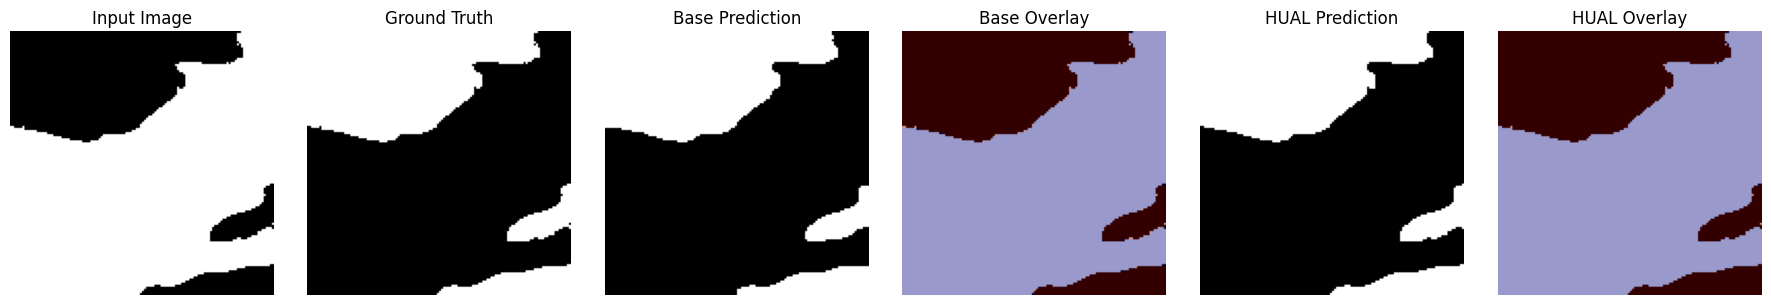

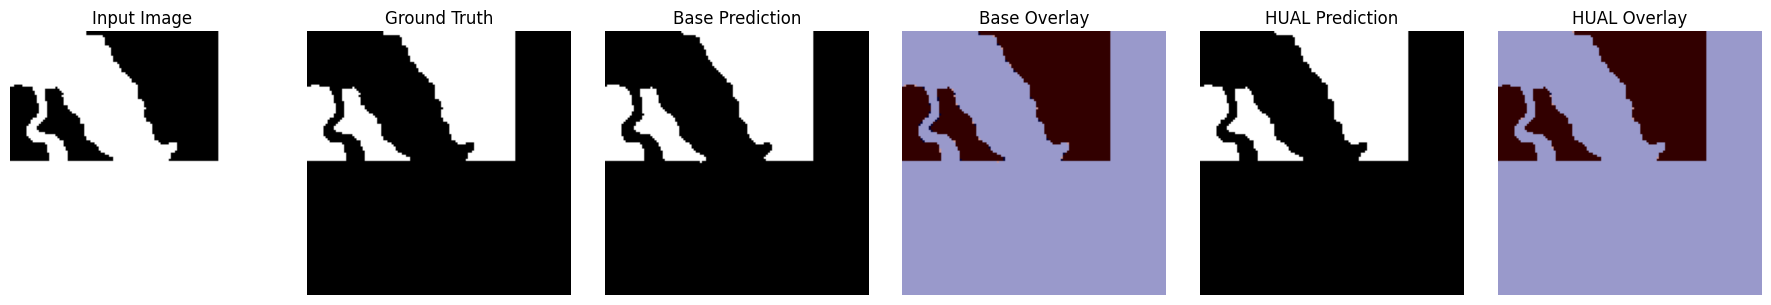

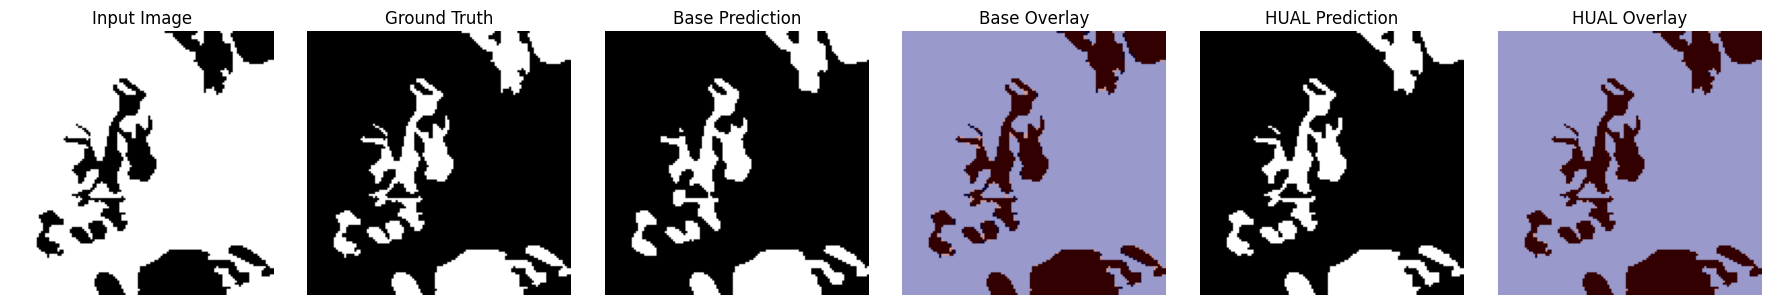

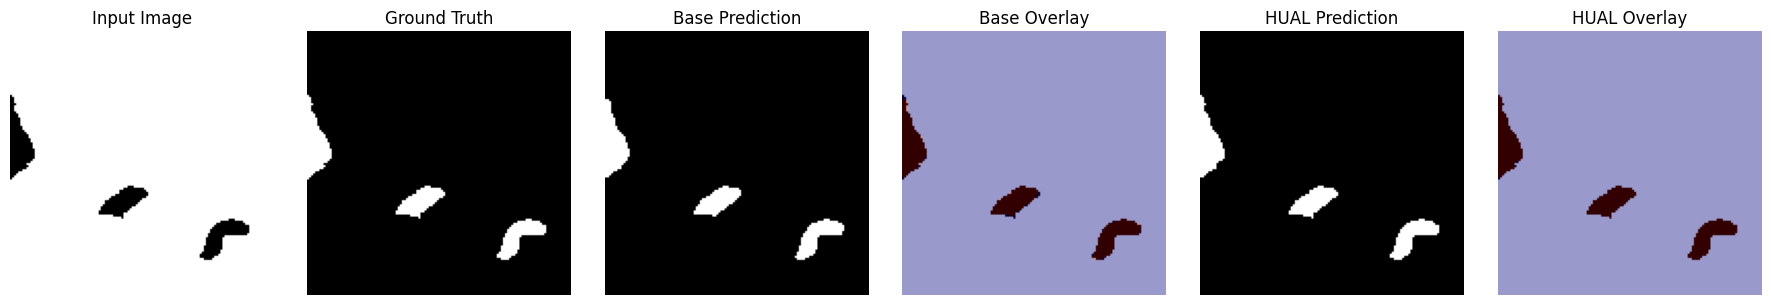

In [ ]:
# Dataset
test_dataset = GlacierDataset(X_test, Y_test)

base_model_path = "unet_best_glacier.pth"
hual_model_path = "unet_hual_finetuned.pth"

in_channels = 17

# Load BASE model
base_checkpoint = torch.load(base_model_path, map_location=DEVICE, weights_only=False)
base_model = make_strong_unet(in_channels)
base_model.load_state_dict(base_checkpoint["model_state_dict"])
base_model.to(DEVICE)

# Load HUAL model
hual_checkpoint = torch.load(hual_model_path, map_location=DEVICE, weights_only=False)
hual_model = make_strong_unet(in_channels)
hual_model.load_state_dict(hual_checkpoint)
hual_model.to(DEVICE)

# Indices to visualize (multiple patches)
idx_list = [2, 11, 12, 13]

# Visualize
visualize_base_vs_hual_predictions(
    base_model=base_model,
    hual_model=hual_model,
    dataset=test_dataset,
    idx_list=idx_list,
    threshold=0.4,
    device=DEVICE,
    channel=0  # optical channel
)


In [ ]:
# Uncertainty Reduction Before HUAL vs After HUAL
"""
Did HUAL actually reduce the model's confusion at glacier boundaries
Before HUAL
- Model is confused near glacier edges - high entropy
After HUAL
- Model is more confident - lower entropy at the same regions
"""

def compute_entropy_for_dataset(model, dataloader, device):
    model.eval()
    entropy_vals = []

    with torch.no_grad():
        for xb, _ in dataloader:
            xb = xb.to(device)

            logits = model(xb)
            probs = torch.sigmoid(logits)

            entropy = -(
                probs * torch.log(probs + 1e-6) +
                (1 - probs) * torch.log(1 - probs + 1e-6)
            )

            entropy_vals.append(entropy.cpu().view(-1))

    return torch.cat(entropy_vals).numpy()


In [ ]:

entropy_base = compute_entropy_for_dataset(
    base_model, test_loader, DEVICE
)

entropy_hual = compute_entropy_for_dataset(
    hual_model, test_loader, DEVICE
)

print("Mean entropy (Base):", entropy_base.mean())
print("Mean entropy (HUAL):", entropy_hual.mean())


Mean entropy (Base): 0.079498716
Mean entropy (HUAL): 0.0018922386


### Result interpretation
- Mean entropy (HUAL model) < Mean entropy (Base model)
- This shows that after HUAL retraining, the overall predictive entropy decreases.
- It indicates the model is more confident, particularly around previously ambiguous glacier boundary regions.

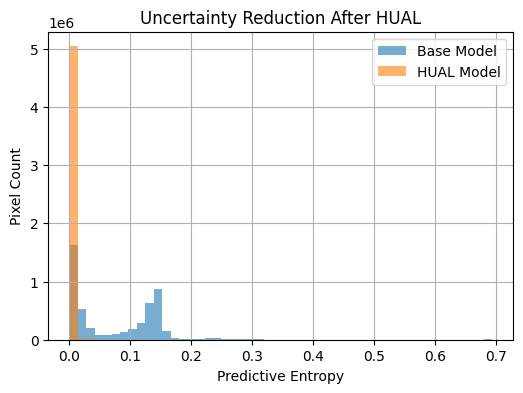

In [ ]:
# plot entropy distribution for Base Model vs HUAL Model

plt.figure(figsize=(6,4))
plt.hist(entropy_base, bins=50, alpha=0.6, label="Base Model")
plt.hist(entropy_hual, bins=50, alpha=0.6, label="HUAL Model")

plt.xlabel("Predictive Entropy")
plt.ylabel("Pixel Count")
plt.title("Uncertainty Reduction After HUAL")
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-270388565.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


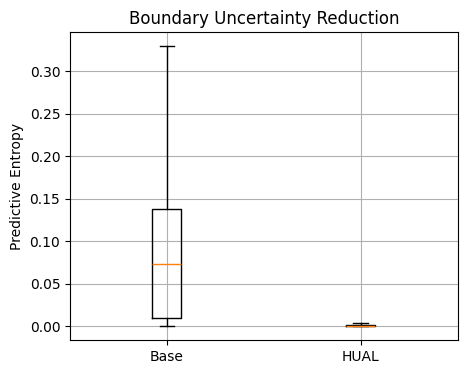

In [ ]:
plt.figure(figsize=(5,4))
plt.boxplot(
    [entropy_base, entropy_hual],
    labels=["Base", "HUAL"],
    showfliers=False
)
plt.ylabel("Predictive Entropy")
plt.title("Boundary Uncertainty Reduction")
plt.grid(True)
plt.show()

### **Why 400 uncertain patches was selected ?**
- we selected the top 400 most uncertain patches (~20% of training data), as this subset sufficiently captures the majority of ambiguous glacier boundary regions.
- it enabled effective boundary refinement without requiring full re-annotation of the dataset.
- HUAL framework achieves improved DICE and IOU scores compared to baseline.
- this approach effectively reduced annotation effort by approximately 72% relative to full dataset annotation.


#### **Why this HUAL approach is better than random sampling ?**
- Because the model is already good in identifying glacier/background regions in clear pixels. The issue was only in the boundary non-clear pixels.
- so if random sampling would have caused us to spend a significant portion of the budget on easy, already-correct regions, result in lower information gain per annotation.
- But HUAL concentrated more on regions where the model is uncertain -- primarily glacier boundaries.